# 🏠 Prix immobiliers IDF — Modélisation prédictive
## Notebook 2/2 : Feature engineering & ML

**Auteur :** Diogo Almeida
**Objectif :** Prédire le prix d'un bien immobilier à partir de ses caractéristiques.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px
import plotly.graph_objects as go
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("..") / "data" / "processed"
MODELS = Path("..") / "models"
ASSETS = Path("..") / "assets"
MODELS.mkdir(parents=True, exist_ok=True)

In [4]:
# Charger les données nettoyées
df = pd.read_csv(DATA_PROCESSED / "dvf_clean.csv")
print(f"Dataset : {len(df):,} lignes")
display(df.head())

Dataset : 469,265 lignes


,date_mutation,annee,mois,prix,surface,nb_pieces,type_local,departement,nom_commune,code_postal,lat,lon,prix_m2
0,2022-01-04,2022,1,580000.0,25.0,2.0,Appartement,75,Paris 18e Arrondissement,75018.0,48.884490,2.348168,23200.000000
1,2022-01-06,2022,1,605000.0,42.0,3.0,Appartement,75,Paris 3e Arrondissement,75003.0,48.863374,2.362871,14404.761905
2,2022-01-05,2022,1,716250.0,69.0,3.0,Appartement,75,Paris 9e Arrondissement,75009.0,48.880353,2.332324,10380.434783
3,2022-01-05,2022,1,320000.0,33.0,2.0,Appartement,75,Paris 10e Arrondissement,75010.0,48.879658,2.362613,9696.969697
4,2022-01-07,2022,1,320000.0,29.0,1.0,Appartement,75,Paris 20e Arrondissement,75020.0,48.872782,2.405513,11034.482759


## 1. Feature Engineering

Créer des variables exploitables par les modèles ML.

In [5]:
# Features de base
df["log_surface"] = np.log1p(df["surface"])
df["pieces_par_surface"] = df["nb_pieces"] / df["surface"]
df["est_paris"] = (df["departement"] == "75").astype(int)

# Distance approximative au centre de Paris (km)
PARIS_LAT, PARIS_LON = 48.8566, 2.3522
df["dist_paris_km"] = np.sqrt(
    ((df["lat"] - PARIS_LAT) * 111) ** 2 +
    ((df["lon"] - PARIS_LON) * 111 * np.cos(np.radians(48.85))) ** 2
)

# Encoder le département
le_dep = LabelEncoder()
df["dep_encoded"] = le_dep.fit_transform(df["departement"])

# Encoder le type de bien
df["est_appartement"] = (df["type_local"] == "Appartement").astype(int)

# Année et mois de la transaction
df["annee_num"] = df["annee"]
df["mois_num"] = df["mois"]

print(f"Features créées ✓")
print(f"Colonnes : {df.shape[1]}")

Features créées ✓
Colonnes : 21


In [6]:
# Sélection des features pour le modèle
FEATURES = [
    "surface", "nb_pieces", "log_surface", "pieces_par_surface",
    "est_paris", "dist_paris_km", "dep_encoded", "est_appartement",
    "lat", "lon", "annee_num", "mois_num",
]
TARGET = "prix"

# Supprimer les NaN dans les features
df_model = df[FEATURES + [TARGET]].dropna()
print(f"Dataset modèle : {len(df_model):,} lignes × {len(FEATURES)} features")

X = df_model[FEATURES]
y = df_model[TARGET]

Dataset modèle : 469,265 lignes × 12 features


## 2. Split train/test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

Train : 375,412 | Test : 93,853


## 3. Benchmark de modèles

In [8]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Entraîne et évalue un modèle."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  MAE  : {mae:,.0f} €")
    print(f"  RMSE : {rmse:,.0f} €")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*50}")

    return {"name": name, "model": model, "mae": mae, "rmse": rmse, "r2": r2, "y_pred": y_pred}

results = []

# 1. Linear Regression
res_lr = evaluate("Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test)
results.append(res_lr)

# 2. Random Forest
res_rf = evaluate("Random Forest", RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=10, random_state=42, n_jobs=-1
), X_train, y_train, X_test, y_test)
results.append(res_rf)

# 3. XGBoost
res_xgb = evaluate("XGBoost", XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
), X_train, y_train, X_test, y_test)
results.append(res_xgb)


  Linear Regression
  MAE  : 158,368 €
  RMSE : 254,126 €
  R²   : 0.4851

  Random Forest
  MAE  : 88,936 €
  RMSE : 167,891 €
  R²   : 0.7753

  XGBoost
  MAE  : 88,160 €
  RMSE : 164,498 €
  R²   : 0.7843


,name,mae,rmse,r2
0,Linear Regression,158367.950164,254126.305165,0.485129
1,Random Forest,88936.113655,167891.472173,0.775273
2,XGBoost,88160.189404,164498.355189,0.784264


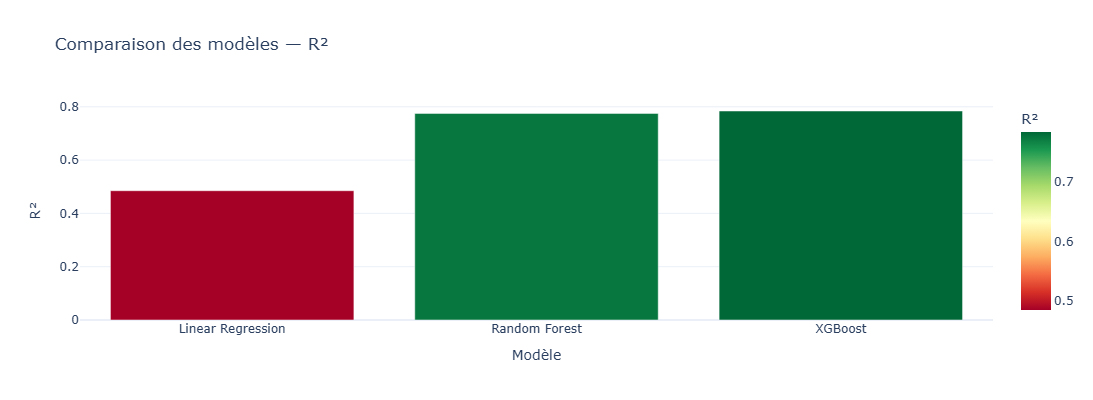

In [9]:
# Comparaison visuelle
df_results = pd.DataFrame(results)[["name", "mae", "rmse", "r2"]]
display(df_results)

fig = px.bar(
    df_results, x="name", y="r2",
    title="Comparaison des modèles — R²",
    labels={"name": "Modèle", "r2": "R²"},
    color="r2", color_continuous_scale="RdYlGn",
    template="plotly_white",
)
fig.update_layout(height=400)
fig.show()
fig.write_image(ASSETS / "06_benchmark_modeles.png", scale=2)

## 4. Analyse du meilleur modèle

Meilleur modèle : XGBoost (R² = 0.7843)


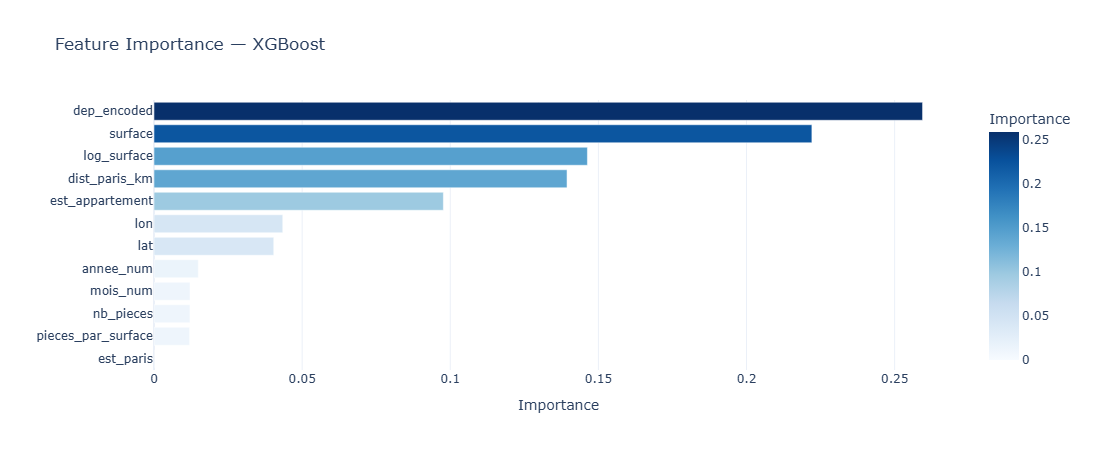

In [10]:
# Prendre le meilleur modèle (R² le plus élevé)
best = max(results, key=lambda x: x["r2"])
print(f"Meilleur modèle : {best['name']} (R² = {best['r2']:.4f})")

# Feature importance
model = best["model"]
if hasattr(model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature": FEATURES,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=True)

    fig = px.bar(
        fi, x="importance", y="feature", orientation="h",
        title=f"Feature Importance — {best['name']}",
        labels={"importance": "Importance", "feature": ""},
        color="importance", color_continuous_scale="Blues",
        template="plotly_white",
    )
    fig.update_layout(height=450)
    fig.show()
    fig.write_image(ASSETS / "07_feature_importance.png", scale=2)

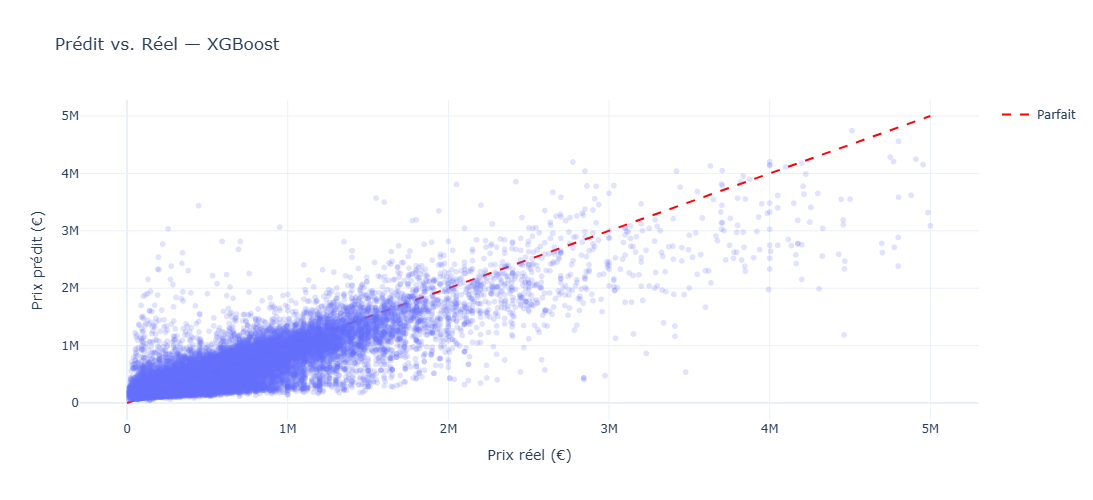

In [11]:
# Prédit vs Réel
y_pred = best["y_pred"]

fig = px.scatter(
    x=y_test, y=y_pred,
    title=f"Prédit vs. Réel — {best['name']}",
    labels={"x": "Prix réel (€)", "y": "Prix prédit (€)"},
    opacity=0.2, template="plotly_white", height=500,
)
fig.add_trace(go.Scatter(
    x=[0, y_test.max()], y=[0, y_test.max()],
    mode="lines", name="Parfait", line=dict(color="red", dash="dash"),
))
fig.show()
fig.write_image(ASSETS / "08_predit_vs_reel.png", scale=2)

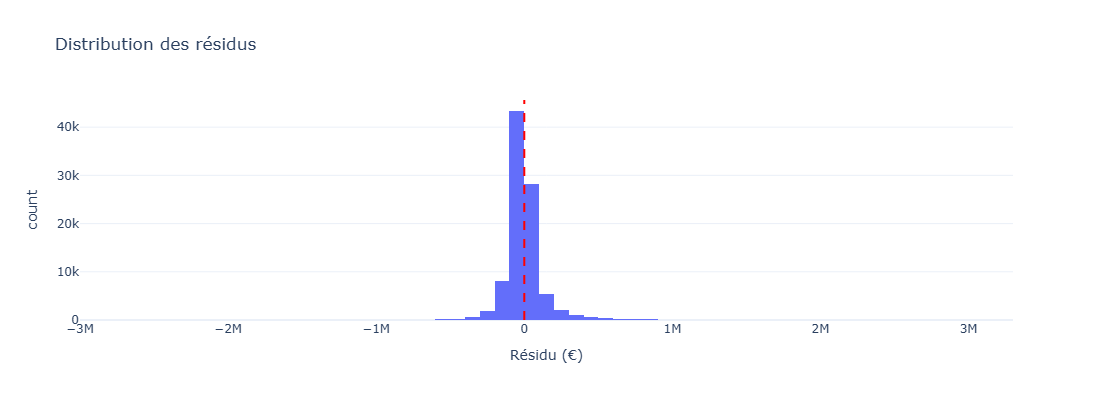

In [12]:
# Analyse des résidus
residus = y_test.values - y_pred

fig = px.histogram(
    x=residus, nbins=100,
    title="Distribution des résidus",
    labels={"x": "Résidu (€)"},
    template="plotly_white",
)
fig.add_vline(x=0, line_dash="dash", line_color="red")
fig.update_layout(height=400)
fig.show()

## 5. Sauvegarde du modèle

In [13]:
# Sauvegarder le meilleur modèle + les encoders
joblib.dump(best["model"], MODELS / "best_model.pkl")
joblib.dump(le_dep, MODELS / "label_encoder_dep.pkl")
joblib.dump(FEATURES, MODELS / "features_list.pkl")

print(f"✓ Modèle sauvegardé : {best['name']}")
print(f"  R² = {best['r2']:.4f}")
print(f"  MAE = {best['mae']:,.0f} €")
print(f"  Features : {FEATURES}")

✓ Modèle sauvegardé : XGBoost
  R² = 0.7843
  MAE = 88,160 €
  Features : ['surface', 'nb_pieces', 'log_surface', 'pieces_par_surface', 'est_paris', 'dist_paris_km', 'dep_encoded', 'est_appartement', 'lat', 'lon', 'annee_num', 'mois_num']


---

*Notebook réalisé par Diogo Almeida — Septembre 2026*
*Données : DVF — DGFiP — Licence Ouverte*